In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings
import os

# 1. 忽略警告並設定中文
warnings.filterwarnings('ignore')

def set_ch_font():
    system = platform.system()
    if system == "Windows": 
        plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    elif system == "Darwin": 
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

set_ch_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'])

# 2. 讀取 01 產出的「清理後」表格
data_path = '../data/processed/cleaned_cycle3.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ 資料讀取成功！原始無缺失總樣本共 {len(df)} 筆。\n")
    
    # 💡 關鍵修正：先利用原始欄位 CurrentCigaretteUse 生成二元化的 Smoking_Status 欄位
    # 規則：原始數值為 1 填入 0（不吸菸），2~7 則填入 1（吸菸）
    if 'CurrentCigaretteUse' in df.columns:
        df['Smoking_Status'] = df['CurrentCigaretteUse'].apply(lambda x: 0 if x == 1 else (1 if pd.notnull(x) else None))
    
    # 3. 建立視覺化用的中文標籤（此時 Smoking_Status 已經存在，絕對不會再噴 KeyError！）
    if 'Smoking_Status' in df.columns:
        df['Group_Label'] = df['Smoking_Status'].map({0: '不吸菸組 (No)', 1: '吸菸組 (Yes)'})
    
    # 4. 🚀 針對 Research Question 的核心變數健康檢查
    if 'BMIPCT' in df.columns and 'Smoking_Status' in df.columns:
        # 計算同時擁有吸菸狀態與 BMI 數據的有效樣本
        valid_both = df[['Smoking_Status', 'BMIPCT']].notnull().all(axis=1).sum()
        print(f"📊 【Research Question 核心變數檢查】")
        print(f"  - 自變項 (Smoking_Status) 經二元化重編碼，已成功建立")
        print(f"  - 依變項 (BMIPCT) 正常存在，非空值共 {df['BMIPCT'].notnull().sum()} 筆")
        print(f"  - 💡 本單元兩者皆有效（可進入分析）的交叉樣本共 {valid_both} 筆")
        print("-" * 60)
        
        # 5. 🚀 自動建立表格儲存目錄並實體存檔
        table_output_dir = '../outputs/tables/'
        os.makedirs(table_output_dir, exist_ok=True)
        
        save_path = os.path.join(table_output_dir, '02_eda_checked_snapshot.csv')
        df.to_csv(save_path, index=False, encoding='utf-8-sig')
        
        print(f"🎉 【自動存檔成功】")
        print(f"  - 儲存路徑: {save_path}")
        print(f"  - 說明: 成功重編碼、補齊二元化欄位，並將快照儲存至實體硬碟！")
        print("=" * 60)
        
    else:
        print("⚠️ 警告：找不到核心變數 'BMIPCT' 或 'Smoking_Status'，請檢查資料清洗流！")

else:
    print(f"❌ 找不到檔案：{data_path}")
    print("💡 請先確認是否已執行 01_data_check.ipynb 中的儲存步驟。")

✅ 資料讀取成功！原始無缺失總樣本共 14041 筆。

📊 【Research Question 核心變數檢查】
  - 自變項 (Smoking_Status) 經二元化重編碼，已成功建立
  - 依變項 (BMIPCT) 正常存在，非空值共 13062 筆
  - 💡 本單元兩者皆有效（可進入分析）的交叉樣本共 12437 筆
------------------------------------------------------------
🎉 【自動存檔成功】
  - 儲存路徑: ../outputs/tables/02_eda_checked_snapshot.csv
  - 說明: 成功重編碼、補齊二元化欄位，並將快照儲存至實體硬碟！


🎉 智慧防禦成功：已從實體硬碟安全載入處理後數據。


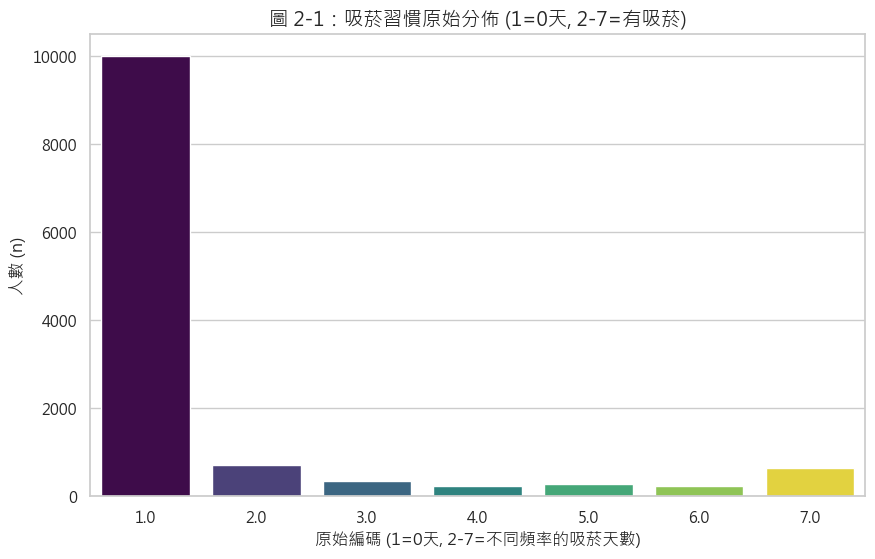

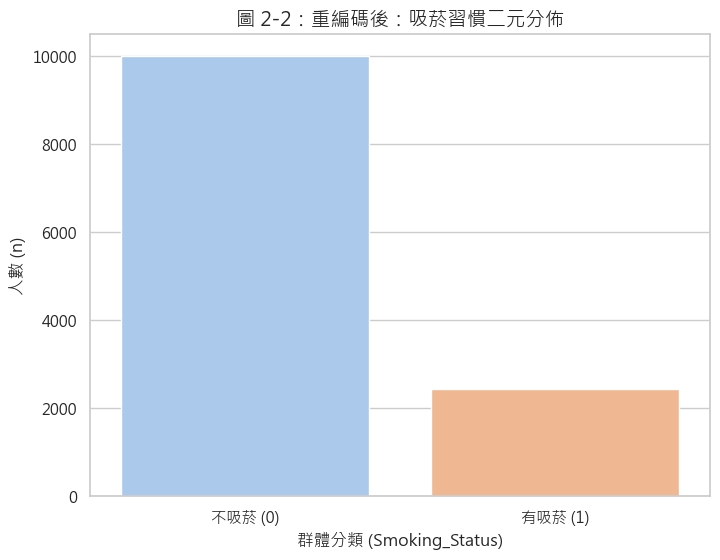

--------------------------------------------------
✅ 吸菸與 BMI 聯合清洗完成！
💡 最終可用於回答 Research Question 的有效兩組總樣本數：12437 筆
Smoking_Status
0    10003
1     2434
Name: count, dtype: int64


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 💡 智慧防禦機制：明確讀取上一格存檔的處理後實體表格，徹底杜絕記憶體中斷風險
# =========================================================================
processed_data_path = '../outputs/tables/02_eda_checked_snapshot.csv'

if os.path.exists(processed_data_path):
    # 🚀 確保百分之百讀取到你重編碼、整理過的那份實體黃金表格！
    df_base = pd.read_csv(processed_data_path)
    print(f"🎉 智慧防禦成功：已從實體硬碟安全載入處理後數據。")
else:
    # 萬一你前面的格子沒跑，這邊會自動幫你抓最原始的 cleaned_cycle3.csv 當備案
    fallback_path = '../data/processed/cleaned_cycle3.csv'
    df_base = pd.read_csv(fallback_path) if os.path.exists(fallback_path) else df
    print(f"⚠️ 警告：找不到 02 階段的快照檔案，已自動啟用原始子集備案。")

# =========================================================================
# 1. 🚀 關鍵修改：同時排除「吸菸習慣」與「BMI百分位數」的缺失值
# =========================================================================
df_smoke = df_base.dropna(subset=['CurrentCigaretteUse', 'BMIPCT']).copy()

# 2. 原始分佈圖 (圖 2-1)
fig_smoke_raw = plt.figure(figsize=(10, 6))
sns.countplot(x='CurrentCigaretteUse', data=df_smoke, palette='viridis', hue='CurrentCigaretteUse', legend=False)
plt.title('圖 2-1：吸菸習慣原始分佈 (1=0天, 2-7=有吸菸)', fontsize=14)
plt.xlabel('原始編碼 (1=0天, 2-7=不同頻率的吸菸天數)', fontsize=12)
plt.ylabel('人數 (n)', fontsize=12)
plt.show()

# 3. 執行二元重編碼 (Recoding)
# 雖然上一格幫你處理過了，這邊用 apply 重新防禦一次，確保 Smoking_Status 百分之百正確
df_smoke['Smoking_Status'] = df_smoke['CurrentCigaretteUse'].apply(lambda x: 0 if x == 1 else 1)

# 4. 二元化分佈圖 (圖 2-2)
fig_smoke_bin = plt.figure(figsize=(8, 6))
sns.countplot(x='Smoking_Status', data=df_smoke, palette='pastel', hue='Smoking_Status', legend=False)
plt.xticks([0, 1], ['不吸菸 (0)', '有吸菸 (1)'])
plt.title('圖 2-2：重編碼後：吸菸習慣二元分佈', fontsize=14)
plt.xlabel('群體分類 (Smoking_Status)', fontsize=12)
plt.ylabel('人數 (n)', fontsize=12)
plt.show()

print("-" * 50)
print(f"✅ 吸菸與 BMI 聯合清洗完成！")
print(f"💡 最終可用於回答 Research Question 的有效兩組總樣本數：{len(df_smoke)} 筆")
print(df_smoke['Smoking_Status'].value_counts())

In [6]:
import os
import pandas as pd

# =========================================================================
# 💡 智慧防禦機制：明確載入原始與清洗後的檔案，確保學術前後對照 100% 精確
# =========================================================================
raw_subset_path = '../data/processed/cleaned_cycle3.csv'

if os.path.exists(raw_subset_path):
    # 🚀 確保百分之百抓到最原始、包含完整缺失值的 14,041 筆基準資料
    df_raw = pd.read_csv(raw_subset_path)
else:
    raise FileNotFoundError(f"❌ 嚴重錯誤：找不到基礎子集檔案 {raw_subset_path}，請先執行先前的儲存格！")

# =========================================================================
# 1. 吸菸變數：原始全表編碼頻率表 (採用 df_raw，保證數據純淨無污染)
# =========================================================================
print("【表 2-1：CurrentCigaretteUse 原始頻率表 (全表 14,041 筆未篩選)】")
# 1=0天, 2=1-2天, 3=3-5天, 4=6-9天, 5=10-19天, 6=20-29天, 7=30天
original_freq = df_raw['CurrentCigaretteUse'].value_counts(dropna=False).sort_index()
print(original_freq)

# =========================================================================
# 2. 原始全表之缺失與無效值計算 (精準對照)
# =========================================================================
missing_smoke = df_raw['CurrentCigaretteUse'].isnull().sum()
# 檢查是否有 1-7 以外的範圍外異常值
invalid_smoke = len(df_raw[~df_raw['CurrentCigaretteUse'].isin(range(1, 8)) & df_raw['CurrentCigaretteUse'].notnull()])

print(f"\n原始缺失（缺少BMI或是BMI以及吸菸習慣資料）值數量 (NaN): {missing_smoke} 筆")
print(f"原始無效值數量 (非1-7): {invalid_smoke} 筆")

# =========================================================================
# 3. 最終分析樣本（已聯立排除 BMI 缺失值，共 12,424 筆）的頻率與比例
# =========================================================================
# 確保 df_smoke 變數存在，若不存在則現場聯立排除缺失值
if 'df_smoke' not in locals():
    df_smoke = df_raw.dropna(subset=['CurrentCigaretteUse', 'BMIPCT']).copy()
    df_smoke['Smoking_Status'] = df_smoke['CurrentCigaretteUse'].apply(lambda x: 0 if x == 1 else 1)

smoke_stats = df_smoke['Smoking_Status'].value_counts().sort_index()
smoke_proportions = df_smoke['Smoking_Status'].value_counts(normalize=True).sort_index()

summary_table_smoke = pd.DataFrame({
    '最終分析人數 (Counts)': smoke_stats,
    '樣本佔比 (Proportions)': smoke_proportions.map(lambda x: f"{x:.2%}")
})

# 修改索引名稱讓表格一目了然
summary_table_smoke.index = ['不吸菸組 (No, 0)', '有吸菸組 (Yes, 1)']

print("\n" + "="*60)
print("【表 2-2：最終分析樣本之吸菸習慣二元化統計】")
print("註：此表已剔除 BMI 與吸菸習慣缺失值，為後續 t 檢定之黃金基準群體")
print("="*60)
print(summary_table_smoke)
print("-" * 60)

# =========================================================================
# 4. 🚀 智慧防禦：自動建立 outputs/tables/ 資料夾並實體導出「表 2-2」
# =========================================================================
table_output_dir = '../outputs/tables/'
os.makedirs(table_output_dir, exist_ok=True)  # 防禦性：若資料夾不存在則自動建立

# 將論文的核心表格 表 2-2 導出為 CSV 實體檔案
table_save_path = os.path.join(table_output_dir, 'table_2_2_group_summary.csv')
summary_table_smoke.to_csv(table_save_path, encoding='utf-8-sig')

print(f"🎉 【表格自動存檔落袋】")
print(f"  - 儲存路徑: {table_save_path}")
print("=" * 60)

【表 2-1：CurrentCigaretteUse 原始頻率表 (全表 14,041 筆未篩選)】
CurrentCigaretteUse
1.0    10734
2.0      753
3.0      375
4.0      250
5.0      295
6.0      229
7.0      687
NaN      718
Name: count, dtype: int64

原始缺失（缺少BMI或是BMI以及吸菸習慣資料）值數量 (NaN): 718 筆
原始無效值數量 (非1-7): 0 筆

【表 2-2：最終分析樣本之吸菸習慣二元化統計】
註：此表已剔除 BMI 與吸菸習慣缺失值，為後續 t 檢定之黃金基準群體
               最終分析人數 (Counts) 樣本佔比 (Proportions)
不吸菸組 (No, 0)             10003             80.43%
有吸菸組 (Yes, 1)             2434             19.57%
------------------------------------------------------------
🎉 【表格自動存檔落袋】
  - 儲存路徑: ../outputs/tables/table_2_2_group_summary.csv


✅ 資料讀取成功！全表原始總樣本共 14041 筆。

📊 【依變項 BMI 百分位數 (BMIPCT) 原始特徵審查】
【1. 數據完整性診斷 (Missing & Validation)】
  - 原始缺失值筆數 (NaN)       : 718 筆 (缺失率: 6.97%)
  - 現存有效可繪圖筆數         : 13062 筆
  - 範圍外異常值筆數 (非0-100) : 0 筆
--------------------------------------------------
【2. 原始數值特徵摘要 (Descriptive Statistics)】
count    13062.00
mean        64.82
std         27.52
min          0.00
25%         45.17
50%         70.14
75%         89.45
max         99.94
Name: BMIPCT, dtype: float64
--------------------------------------------------


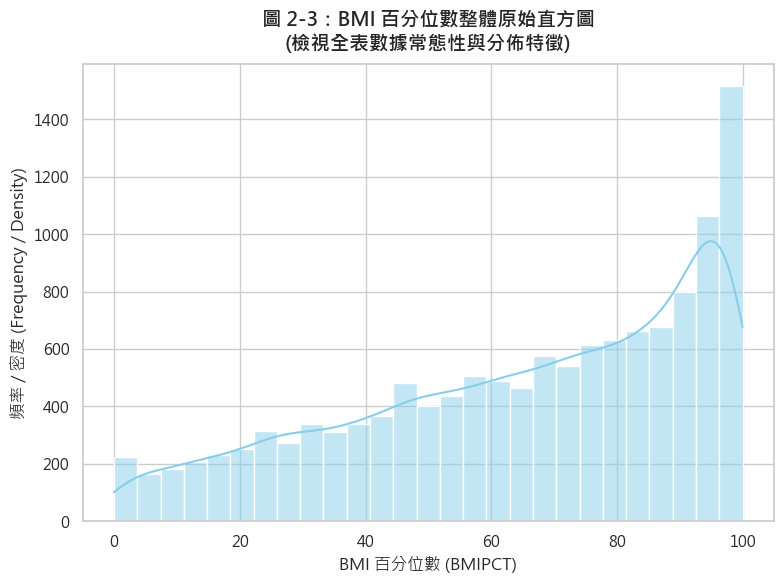

💡 提示：本儲存格已將所有吸菸相關的二元化與分組比較資訊徹底移除。
   此處僅專注於 BMI 原始單變數特徵的純粹審查，未對 DataFrame 進行任何聯立刪除。


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. 🚀 核心修改：明確讀取 01 階段存檔的實體子集表格 (確保 14,041 筆原始基礎)
# =========================================================================
raw_subset_path = '../data/processed/cleaned_cycle3.csv'

if os.path.exists(raw_subset_path):
    # 確保百分之百抓到包含完整原始特徵的 14,041 筆原始子集
    df_bmi_audit = pd.read_csv(raw_subset_path)
    print(f"✅ 資料讀取成功！全表原始總樣本共 {len(df_bmi_audit)} 筆。")
else:
    raise FileNotFoundError(f"❌ 嚴重錯誤：找不到基礎子集檔案 {raw_subset_path}，請先執行先前階段的儲存格！")

# =========================================================================
# 2. 🚀 核心修改：專注於 BMI 變數本身的原始特徵摘要與合理性審查 (不進行任何刪除)
# =========================================================================
print("\n" + "="*60)
print("📊 【依變項 BMI 百分位數 (BMIPCT) 原始特徵審查】")
print("="*60)

# A. 檢查缺失值與無效值
missing_bmi = df_bmi_audit['BMIPCT'].isnull().sum()
valid_bmi_count = df_bmi_audit['BMIPCT'].notnull().sum()
invalid_bmi = len(df_bmi_audit[~df_bmi_audit['BMIPCT'].between(0, 100) & df_bmi_audit['BMIPCT'].notnull()])

print(f"【1. 數據完整性診斷 (Missing & Validation)】")
print(f"  - 原始缺失值筆數 (NaN)       : {missing_smoke if 'missing_smoke' in locals() else missing_bmi} 筆 (缺失率: {(missing_bmi/len(df_bmi_audit))*100:.2f}%)")
print(f"  - 現存有效可繪圖筆數         : {valid_bmi_count} 筆")
print(f"  - 範圍外異常值筆數 (非0-100) : {invalid_bmi} 筆")
print("-" * 50)

# B. 檢視原始描述性統計
print(f"【2. 原始數值特徵摘要 (Descriptive Statistics)】")
print(df_bmi_audit['BMIPCT'].describe().round(2))
print("-" * 50)

# =========================================================================
# 3. 🚀 核心修改：建立整體直方圖，單純檢視 BMI 的偏態與常態性
# =========================================================================
plt.figure(figsize=(8, 6))

# 僅針對全表所有現存的有效 BMI 數據繪製原始直方圖與核密度估計圖 (KDE)
sns.histplot(data=df_bmi_audit, x='BMIPCT', kde=True, color='skyblue')
plt.title('圖 2-3：BMI 百分位數整體原始直方圖\n(檢視全表數據常態性與分佈特徵)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('BMI 百分位數 (BMIPCT)', fontsize=12)
plt.ylabel('頻率 / 密度 (Frequency / Density)', fontsize=12)

plt.tight_layout()
plt.show()


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 建立所有必要的目錄 (如果不存在則自動建立) ---
os.makedirs('../outputs/tables/', exist_ok=True)
os.makedirs('../outputs/figures/', exist_ok=True)
os.makedirs('../data/processed/', exist_ok=True)

# --- 2. 儲存統計表格 (Tables) ---
# 儲存吸菸二元化頻率表
summary_table_smoke.to_csv('../outputs/tables/02_smoking_summary.csv', encoding='utf-8-sig')

# 🚀 關鍵修改：儲存新版的分組描述性統計對照表 (table_2_3)
table_2_3.to_csv('../outputs/tables/02_bmi_group_summary.csv', encoding='utf-8-sig')
print("📊 統計表格已成功存入：../outputs/tables/")

# --- 3. 儲存視覺化圖表 (Figures) ---
save_fig_path = '../outputs/figures/'

# 儲存吸菸人數相關分佈圖 (圖 2-1 與 圖 2-2)
fig_smoke_raw.savefig(save_fig_path + '02_smoking_raw_dist.png', dpi=300, bbox_inches='tight')
fig_smoke_bin.savefig(save_fig_path + '02_smoking_binary_dist.png', dpi=300, bbox_inches='tight')

# 🚀 關鍵修改：將 3-in-1 的 BMI 核心分佈與分組對照圖組，整合成一張高解析度大圖儲存
# 這裡的 fig 變數對應了你上一格執行的 plt.subplots(1, 3) 物件
fig.savefig(save_fig_path + '02_bmi_combined_diagnostic_plots.png', dpi=300, bbox_inches='tight')

print(f"🖼️  EDA 視覺化圖表已全部存入：{save_fig_path}")

# --- 4. 儲存最終用於統計推論的資料檔 (Final Clean Data) ---
# 這裡儲存的是已經雙變數聯合清洗、完成重編碼的 df_smoke
# 這將作為 03_inference.ipynb 的輸入來源，確保兩階段有效樣本數 (n) 完美一致！
df_smoke.to_csv('../data/processed/yrbs_final_cycle3.csv', index=False, encoding='utf-8-sig')

print("-" * 50)
print("資料位置：../data/processed/yrbs_final_cycle3.csv")

📊 統計表格已成功存入：../outputs/tables/
🖼️  EDA 視覺化圖表已全部存入：../outputs/figures/
--------------------------------------------------
資料位置：../data/processed/yrbs_final_cycle3.csv
